In [1]:
# imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime


In [2]:
# read in data
data = xr.open_dataset("../data/2026-03-17/ECMWF_s2s_pf_precip_forecast_weekly-and-dekade_23N-20W-37S-59E.grib",engine="cfgrib")
#data_mclim = xr.open_mfdataset("D:/Hiwi/EFI_SOT_Kenya/m-climate/*.nc",combine="nested",concat_dim="init_time")

filelist = glob.glob("../m-climate/*.nc")
filelist.sort()
data2 = None
for filepath in filelist:
    data_mclim = xr.open_dataset(filepath)

    # open a new step dimension in order to truly obtain the m-climate for all steps
    first_time = data_mclim["time"].min()
    data_mclim = data_mclim.assign_coords(step=("time",(data_mclim["time"].values - first_time.values)))
    data_mclim = data_mclim.expand_dims("time0")  # keep first date dimension
    data_mclim = data_mclim.assign_coords(time0=[first_time.values])  # only the first date
    data_mclim = data_mclim.swap_dims({"time": "step"})       # use step as the main dim
    data_mclim = data_mclim.drop_vars("time")
    data_mclim = data_mclim.rename({"time0": "time"})

    # concat all initial times in the m-climate
    if data2 is None: data2 = data_mclim
    else: data2 = xr.concat((data2, data_mclim),dim="time")

data_mclim = data2
data_mclim

Ignoring index file '../data/2026-03-17/ECMWF_s2s_pf_precip_forecast_weekly-and-dekade_23N-20W-37S-59E.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 186, step: 6, quantile: 101, latitude: 40, longitude: 42)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2024-11-13 2024-11-15 ... 2025-11-11
  * step       (step) timedelta64[ns] 48B 0 days 7 days ... 28 days 35 days
  * quantile   (quantile) int32 404B 113793886 114907999 ... 190878303
  * latitude   (latitude) float64 320B -36.0 -34.5 -33.0 ... 19.5 21.0 22.5
  * longitude  (longitude) float64 336B -3.0 -1.5 0.0 1.5 ... 55.5 57.0 58.5
Data variables:
    avg_2t     (time, step, quantile, latitude, longitude) float64 2GB 284.5 ...
    tp         (time, step, quantile, latitude, longitude) float64 2GB 1.137e...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 07 16:55:10 2026: cdo remapcon,targetgrid.txt yipin...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [3]:
# convert time dimensions to datetime
mdata = data.copy(deep=True)
mdata["time"] = mdata["time"].expand_dims("time")

print(mdata["time"].shape)
print(mdata["time"].values)


(1,)
['2026-03-17T00:00:00.000000000']


In [4]:
(data["step"] / 10**9 / 60 / 60 / 24).values.astype(int)
data

<xarray.Dataset> Size: 9MB
Dimensions:     (number: 100, step: 11, latitude: 40, longitude: 53)
Coordinates:
  * number      (number) int64 800B 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * step        (step) timedelta64[ns] 88B 0 days 7 days ... 40 days 42 days
    valid_time  (step) datetime64[ns] 88B ...
  * latitude    (latitude) float64 320B 22.5 21.0 19.5 ... -33.0 -34.5 -36.0
  * longitude   (longitude) float64 424B -19.5 -18.0 -16.5 ... 55.5 57.0 58.5
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    tp          (number, step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-23T09:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
data_mclim = data2
data_mclim

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 186, step: 6, quantile: 101, latitude: 40, longitude: 42)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2024-11-13 2024-11-15 ... 2025-11-11
  * step       (step) timedelta64[ns] 48B 0 days 7 days ... 28 days 35 days
  * quantile   (quantile) int32 404B 113793886 114907999 ... 190878303
  * latitude   (latitude) float64 320B -36.0 -34.5 -33.0 ... 19.5 21.0 22.5
  * longitude  (longitude) float64 336B -3.0 -1.5 0.0 1.5 ... 55.5 57.0 58.5
Data variables:
    avg_2t     (time, step, quantile, latitude, longitude) float64 2GB 284.5 ...
    tp         (time, step, quantile, latitude, longitude) float64 2GB 1.137e...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 07 16:55:10 2026: cdo remapcon,targetgrid.txt yipin...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [8]:
data

<xarray.Dataset> Size: 9MB
Dimensions:     (number: 100, step: 11, latitude: 40, longitude: 53)
Coordinates:
  * number      (number) int64 800B 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * step        (step) timedelta64[ns] 88B 0 days 7 days ... 40 days 42 days
    valid_time  (step) datetime64[ns] 88B ...
  * latitude    (latitude) float64 320B 22.5 21.0 19.5 ... -33.0 -34.5 -36.0
  * longitude   (longitude) float64 424B -19.5 -18.0 -16.5 ... 55.5 57.0 58.5
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    tp          (number, step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-21T15:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
### bring climatology and forecast to the same dimensions

# rename dims TODO: automatize this for lat and lon
data_changed = mdata.rename({"latitude":"lat","longitude":"lon"})
data_mclim_changed = data_mclim.rename({"avg_2t":"t2m","latitude":"lat","longitude":"lon"})

# bring mclim for precip to mm
#data_mclim_changed["tp"] = data_mclim_changed["tp"]*1000
data_mclim_changed["tp"].attrs["units"] = "mm"

# time
data_changed = data_changed.sel(time=data_changed["time"].dt.month.isin(data_mclim_changed["time"].dt.month))
data_mclim_changed = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.month.isin(data_changed["time"].dt.month))

data_f = data_changed.sel(time=data_changed["time"].dt.day.isin(data_mclim_changed["time"].dt.day))
data_clim = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.day.isin(data_changed["time"].dt.day))

# step
data_f = data_f.sel(step=data_f["step"].isin(data_clim["step"]))
data_clim = data_clim.sel(step=data_clim["step"].isin(data_f["step"]))

# lon and lat
data_f = data_f.sel(lon=data_f["lon"].isin(data_clim["lon"])).sel(lat=data_f["lat"].isin(data_clim["lat"]))
data_clim = data_clim.sel(lon=data_clim["lon"].isin(data_f["lon"])).sel(lat=data_clim["lat"].isin(data_f["lat"]))

# remove accumulation for precipitation
data_f = data_f.diff("step")

data_clim
data_f

<xarray.Dataset> Size: 3MB
Dimensions:     (number: 100, time: 1, step: 5, lat: 40, lon: 42)
Coordinates:
  * number      (number) int64 800B 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * time        (time) datetime64[ns] 8B 2026-03-17
  * step        (step) timedelta64[ns] 40B 7 days 14 days ... 28 days 35 days
    valid_time  (step) datetime64[ns] 40B ...
  * lat         (lat) float64 320B 22.5 21.0 19.5 18.0 ... -33.0 -34.5 -36.0
  * lon         (lon) float64 336B -3.0 -1.5 0.0 1.5 3.0 ... 54.0 55.5 57.0 58.5
    surface     float64 8B ...
Data variables:
    tp          (number, step, lat, lon) float32 3MB 0.4453 0.1172 ... 17.44
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-23T09:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
### establish functions for EFI and SOT

# EFI
def EFI(data,data_mclim,ens_dim):
    '''
    Calculates the extreme forecast index (EFI) for a forecast with respect to the m-climate.
    
    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number

    Returns:
        EFI (xr.ds): The EFI for the given data and climatology
    '''
    p = np.linspace(0.01,0.99,99)

    # compute the p-th quantile of the ensemble dimension for the m-climate
    data_mclim_quantiled = data_mclim.where(~data_mclim["quantile"].isin([0,1]),drop=True)#data_mclim.quantile(p,ens_dim)
    quantile = data_mclim_quantiled["quantile"]

    # calculate Qf and compute the discretized integral w.r.t. p resp. quantile
    Qf = (data.expand_dims({"quantile": quantile}) < data_mclim_quantiled).mean(ens_dim) #(data<data_mclim_quantiled).mean(ens_dim)
    result = 2/np.pi * ((quantile - Qf) / (quantile * (1-quantile))**.5).integrate("quantile")

    return result

# SOT
def SOT(data,data_mclim,ens_dim,upper_lower=False):
    '''
    Calculates the shift of tails from data with respect to the climatology in m-clim, for the difference between .9 and .99 percentiles

    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number
        upper_lower (bool): True if lower SOT (for .01 vs. .1 quantiles) shall be calculated in addition to the upper SOT
        
    Returns:
        SOT (xr.ds): The SOT for the given data and climatology
    '''
    if not upper_lower:
        p = [.9,.99]

        # compute the p-th quantile of the ensemble dimension
        data_mclim_quantiled = data_mclim.where(data_mclim["quantile"].isin(p),drop=True)#data_mclim.quantile(p,ens_dim)
        data_quantiled = data.quantile(p,ens_dim)

        # for readability
        Qf_90 = data_quantiled.sel(quantile=.9)
        Qc_90 = data_mclim_quantiled.sel(quantile=.9)
        Qc_99 = data_mclim_quantiled.sel(quantile=.99)

        # compute SOT
        result = (Qf_90 - Qc_99) / (Qc_99 - Qc_90)

        return result

    else:
        raise NotImplementedError("The lower SOT is not implemented as of now.")
    


In [8]:
### some further preparations

# aggregate the data to weekly forecast
#data_f_calc = data_f.coarsen(step=7, boundary="trim").mean()
data_f_calc = data_f

# set the step which we want to compare
#data_f_calc = data_f_calc.isel(step=0)

# change the entries in the mclimate quantile column to the actual quantiles (due to a data issue)
data_clim_calc = data_clim.assign_coords(quantile=list(np.linspace(0,1,101)))

# align the times to the same year
data_clim_calc = data_clim_calc.assign_coords(time=data_f_calc["time"])#.drop_vars("step"))



#data_f_calc
data_clim_calc

<xarray.Dataset> Size: 16MB
Dimensions:   (time: 1, step: 6, quantile: 101, lat: 40, lon: 42)
Coordinates:
  * time      (time) datetime64[ns] 8B 2026-03-17
  * step      (step) timedelta64[ns] 48B 0 days 7 days ... 28 days 35 days
  * quantile  (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * lat       (lat) float64 320B -36.0 -34.5 -33.0 -31.5 ... 18.0 19.5 21.0 22.5
  * lon       (lon) float64 336B -3.0 -1.5 0.0 1.5 3.0 ... 54.0 55.5 57.0 58.5
    surface   float64 8B ...
Data variables:
    t2m       (time, step, quantile, lat, lon) float64 8MB 288.6 288.6 ... 307.5
    tp        (time, step, quantile, lat, lon) float64 8MB 0.06288 ... 81.14
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 07 16:55:10 2026: cdo remapcon,targetgrid.txt yipin...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [9]:
### calculate

# EFI
efi = EFI(data_f_calc["tp"],data_clim_calc["tp"],"number")

# SOT
sot = SOT(data_f_calc["tp"],data_clim_calc["tp"],"number")


In [ ]:
# ChatGPT plotting function
def plot_map_EFI(
    da_EFI,
    projection=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    cbar_title_upper = "upper EFI",
    cbar_title_lower = "lower EFI",
    title=None,
    figsize=(10,6),
):
    
    # mask EFI values
    da_upper = da_EFI.where(da_EFI >= 0.5)
    da_lower = da_EFI.where(da_EFI <= -0.5)
    
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection}
    )

    levels_upper = np.arange(0.5, 1.01, 0.1)
    levels_lower = np.arange(-1.00, -0.49, 0.1)

    # Create custom colormap: yellow → orange → red
    colors_upper = [
        "#ffff00",  # 0.5 yellow
        "#ffcc00",
        "#ff9900",
        "#ff6600",
        "#ff3300",
        "#ff0000"   # 1.0 red
    ]

    # Create custom colormap: light blue → blue → purple
    colors_lower = [
        "#5ca2fe",  # -0.5 light blue
        "#4457ff",
        "#0000ff",
        "#e100ff",
        "#9d00ff",
        "#42017b"   # -1.0 purple
    ]
    colors_lower = colors_lower[::-1]

    cmap_upper = mcolors.ListedColormap(colors_upper)
    norm_upper = mcolors.BoundaryNorm(levels_upper, cmap_upper.N)
    cmap_lower = mcolors.ListedColormap(colors_lower)
    norm_lower = mcolors.BoundaryNorm(levels_lower, cmap_lower.N)

    # plot data
    im_upper = da_upper.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_upper,
        norm=norm_upper,
        #vmin=vmin,
        #vmax=vmax,
        cbar_kwargs={"shrink": 0.3,"label": cbar_title_upper, "orientation": "horizontal",
        "pad": 0.01,        # distance from plot
        "aspect": 50,       # length vs thickness
        "extend" : "neither",
        }
    )

    im_lower = da_lower.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_lower,
        norm=norm_lower,
        #vmin=vmin,
        #vmax=vmax,
        cbar_kwargs={"shrink": 0.3,"label": cbar_title_lower, "orientation": "horizontal",
        "pad": 0.1,        # distance from plot
        "aspect": 50,       # length vs thickness
        "extend" : "neither",
        }
    )

    # map features
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)

    # gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

def plot_map_SOT(
    da_SOT,
    projection=ccrs.PlateCarree(),
    cmap="coolwarm",
    cbar_title="SOT",
    title=None,
    figsize=(10,6),
):
    
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection}
    )

    # define norm
    da_SOT_non_inf = da_SOT.where(~np.isin(da_SOT,[-np.inf,np.inf]))
    v = max(abs(da_SOT_non_inf.min()), abs(da_SOT_non_inf.max()))
    print(v)
    norm = mcolors.TwoSlopeNorm(vmin=-v,vcenter=0,vmax=v)

    # plot data
    im = da_SOT.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        cbar_kwargs={"label": cbar_title,}
        #norm=norm_upper
        #vmin=vmin,
        #vmax=vmax,
        #cbar_kwargs={"shrink": 0.7}
    )

    # map features
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)

    # gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

<xarray.DataArray 'tp' (step: 5)> Size: 20B
array([ 3.7265625, 34.65625  , 37.617188 , 55.640625 , 46.96875  ],
      dtype=float32)
Coordinates:
  * step        (step) timedelta64[ns] 40B 7 days 14 days ... 28 days 35 days
    valid_time  (step) datetime64[ns] 40B ...
    number      int64 8B 1
    surface     float64 8B ...
    lat         float64 8B 7.5
    lon         float64 8B 12.0
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      2120
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         101
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:  

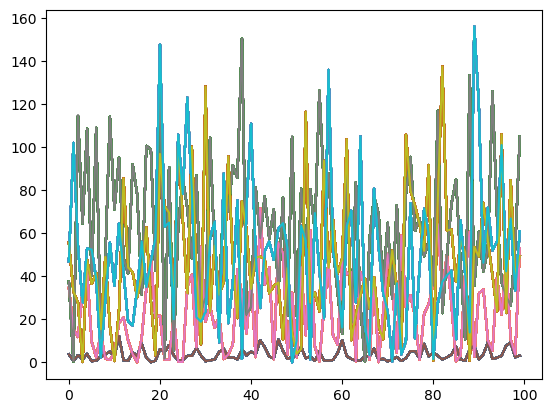

In [44]:
# plots
for number in data_f_calc["number"]:
    plt.plot(data_f_calc["tp"].isel(lat=10,lon=10))
#data_f_calc["tp"].isel(lat=10,lon=10,number=0)
#data_clim["tp"].isel(lat=10,lon=10)
print(data_f_calc["tp"].isel(lat=10,lon=10,number=0))

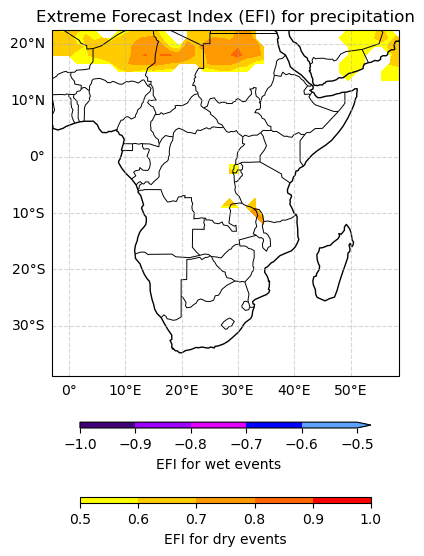

In [55]:
plot_map_EFI(efi.isel(step=3,time=0).drop_vars("time"),title="Extreme Forecast Index (EFI) for precipitation",
             cbar_title_upper="EFI for dry events", cbar_title_lower="EFI for wet events",)
plt.show()
#efi

<xarray.DataArray ()> Size: 8B
array(0.00495445)
Coordinates:
    surface     float64 8B 0.0
    step        timedelta64[ns] 8B 7 days
    lat         float64 8B 0.0
    lon         float64 8B 19.5
    valid_time  datetime64[ns] 8B ...
    time        datetime64[ns] 8B 2026-03-17


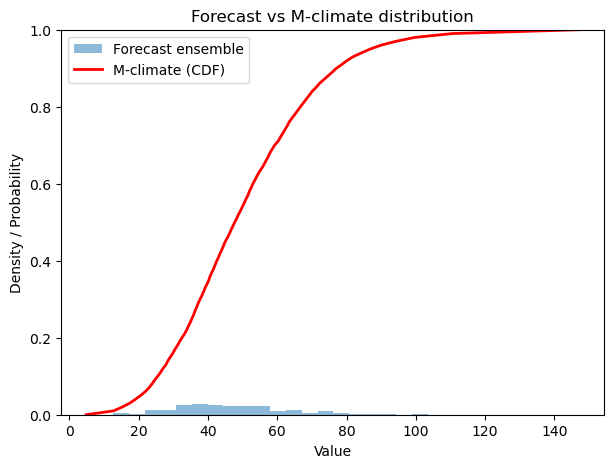

In [58]:
i, j = 0, 19.5  # choose a grid point

fc_point = data_f_calc.sel(lat=i, lon=j).isel(step=0,time=0)
clim_point = data_clim_calc.sel(lat=i, lon=j).isel(step=0,time=0)

quantiles = clim_point["quantile"]
clim_values = clim_point

print(efi.sel(lat=i,lon=j).isel(step=0,time=0))

plt.figure(figsize=(7,5))

# Forecast histogram
plt.hist(fc_point["tp"].values, bins=20, density=True, alpha=0.5, label="Forecast ensemble")

# M-climate as quantile curve (CDF)
plt.plot(clim_values["tp"], quantiles, color="red", lw=2, label="M-climate (CDF)")

plt.xlabel("Value")
plt.ylabel("Density / Probability")
plt.ylim((0,1))
plt.legend()
plt.title("Forecast vs M-climate distribution")
plt.show()

<xarray.DataArray 'tp' ()> Size: 8B
array(inf)
Coordinates:
    step        timedelta64[ns] 8B 7 days
    time        datetime64[ns] 8B 2026-03-17
    valid_time  datetime64[ns] 8B ...
    surface     float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      2120
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         101
    GRIB_units:                               kg m**-2
    standard_name:                            unknown
    long_name:                                Total precipitation
    units:                                    mm


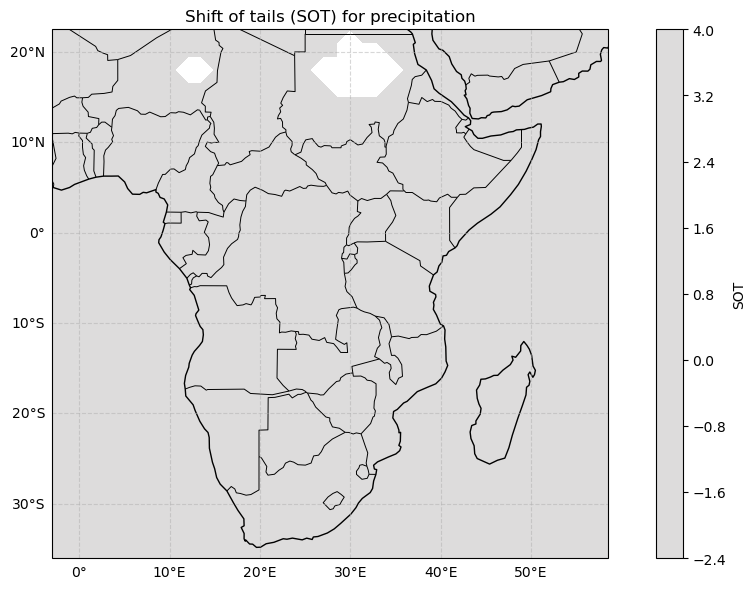

In [75]:
#print(sot)

plot_map_SOT(sot.isel(step=0,time=0))
plt.title("Shift of tails (SOT) for precipitation")
plt.show()